In [65]:
import pandas as  pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from pandas.api.types import is_numeric_dtype
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

# Load the buildin datset "Titanic"

In [ ]:
df =sns.load_dataset("Titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [ ]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


In [ ]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Missing Value Handling

In [ ]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [ ]:
df = df.drop(['deck', 'embarked', 'alive'], axis=1)

In this particular part  'deck','embarked','alive' in those column are not needed for my work.So i just drop those column.

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,Third,man,True,Southampton,False
1,1,1,female,38.0,1,0,71.2833,First,woman,False,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,Third,woman,False,Southampton,True
3,1,1,female,35.0,1,0,53.1000,First,woman,False,Southampton,False
4,0,3,male,35.0,0,0,8.0500,Third,man,True,Southampton,True


Handling the "Age" column nan values

In this part , handling the nan values using mean ..This is the best solution for categorical data

In [ ]:
df['age'] = df['age'].fillna(df['age'].mean())

Using backward fill to handling the nan values on the 'embark_town' column

In [ ]:
df['embark_town'] = df['embark_town'].bfill()

In [ ]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
class          0
who            0
adult_male     0
embark_town    0
alone          0
dtype: int64

In that particular part, all the NaN values are handled successfully.

# EDA

<Axes: xlabel='survived', ylabel='count'>

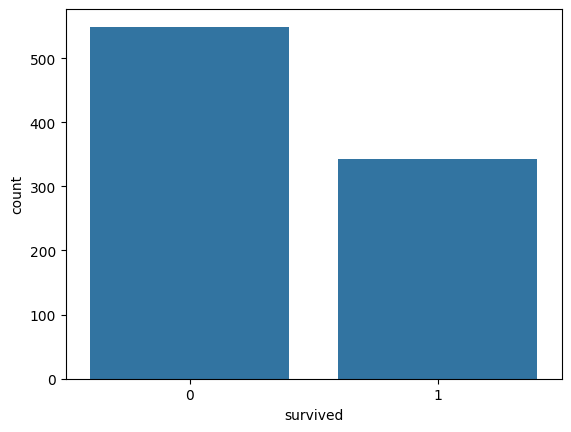

In [ ]:
sns.countplot(x='survived', data = df)

<Axes: xlabel='sex', ylabel='count'>

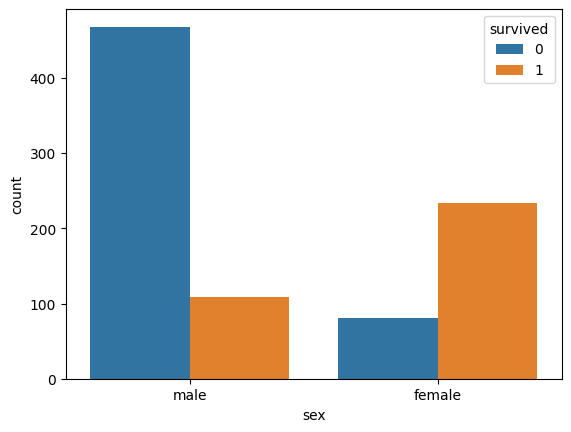

In [ ]:
sns.countplot(x='sex', hue='survived', data=df)

<Axes: xlabel='pclass', ylabel='count'>

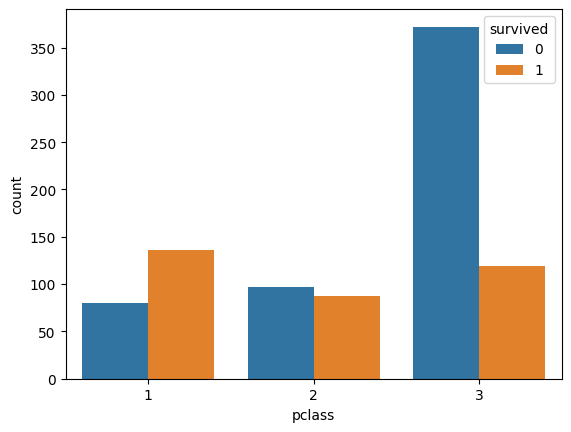

In [ ]:
sns.countplot(x='pclass', hue='survived', data=df)

<Axes: xlabel='survived', ylabel='age'>

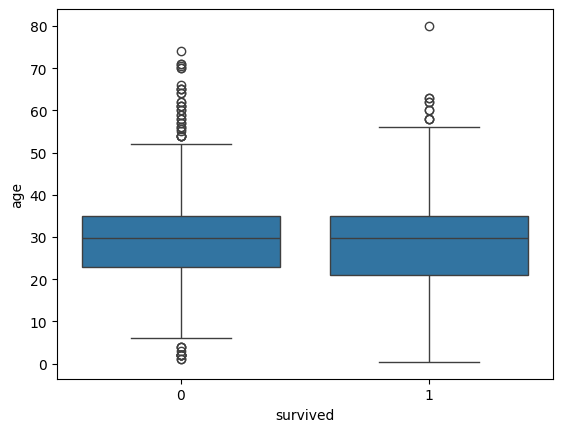

In [ ]:
sns.boxplot(x='survived', y='age', data=df)

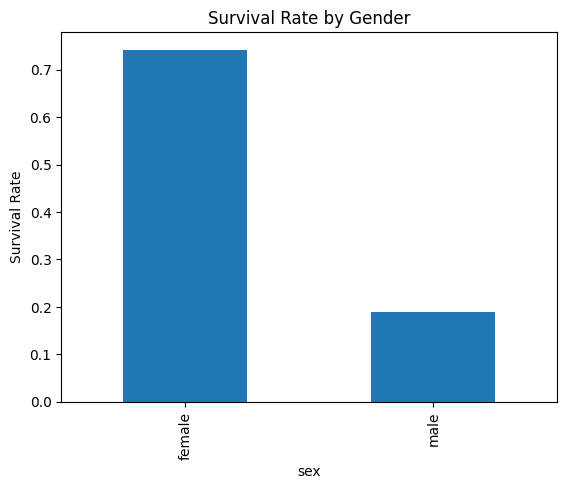

In [ ]:
df.groupby('sex')['survived'].mean().plot(kind='bar')
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.show()

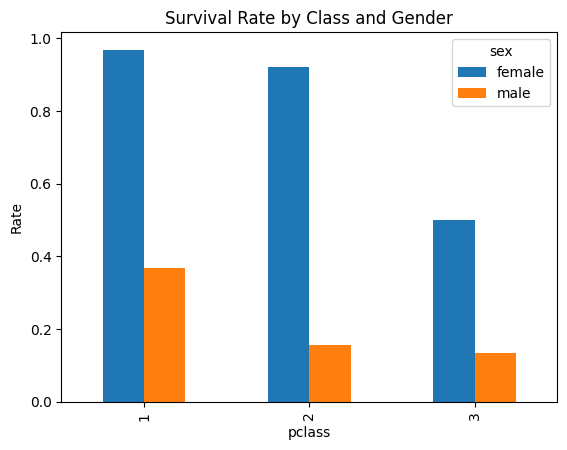

In [ ]:
df.groupby(['pclass','sex'])['survived'].mean().unstack().plot(kind='bar')
plt.title('Survival Rate by Class and Gender')
plt.ylabel('Rate')
plt.show()

# Encoding

In [37]:
# apply labelencoder 
le = LabelEncoder()
for col in df.columns:
    if not is_numeric_dtype(df[col]):
        df[col] = le.fit_transform(df[col])

In [39]:
df.corr()

,survived,pclass,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alone
survived,1.000000,-0.338481,-0.543351,-0.069809,-0.035322,0.081629,0.257307,-0.338481,0.325753,-0.557080,-0.170943,-0.203367
pclass,-0.338481,1.000000,0.131900,-0.331339,0.083081,0.018443,-0.549500,1.000000,-0.196793,0.094035,0.166223,0.135207
sex,-0.543351,0.131900,1.000000,0.084153,-0.114631,-0.245489,-0.182333,0.131900,-0.639773,0.908578,0.111894,0.303646
age,-0.069809,-0.331339,0.084153,1.000000,-0.232625,-0.179191,0.091566,-0.331339,0.354507,0.253236,-0.033737,0.179775
sibsp,-0.035322,0.083081,-0.114631,-0.232625,1.000000,0.414838,0.159651,0.083081,-0.136003,-0.253586,0.069444,-0.584471
parch,0.081629,0.018443,-0.245489,-0.179191,0.414838,1.000000,0.216225,0.018443,-0.055682,-0.349943,0.041064,-0.583398
fare,0.257307,-0.549500,-0.182333,0.091566,0.159651,0.216225,1.000000,-0.549500,0.146290,-0.182024,-0.227015,-0.271832
class,-0.338481,1.000000,0.131900,-0.331339,0.083081,0.018443,-0.549500,1.000000,-0.196793,0.094035,0.166223,0.135207
who,0.325753,-0.196793,-0.639773,0.354507,-0.136003,-0.055682,0.146290,-0.196793,1.000000,-0.437532,-0.067793,0.006540
adult_male,-0.557080,0.094035,0.908578,0.253236,-0.253586,-0.349943,-0.182024,0.094035,-0.437532,1.000000,0.095837,0.404744


<Axes: >

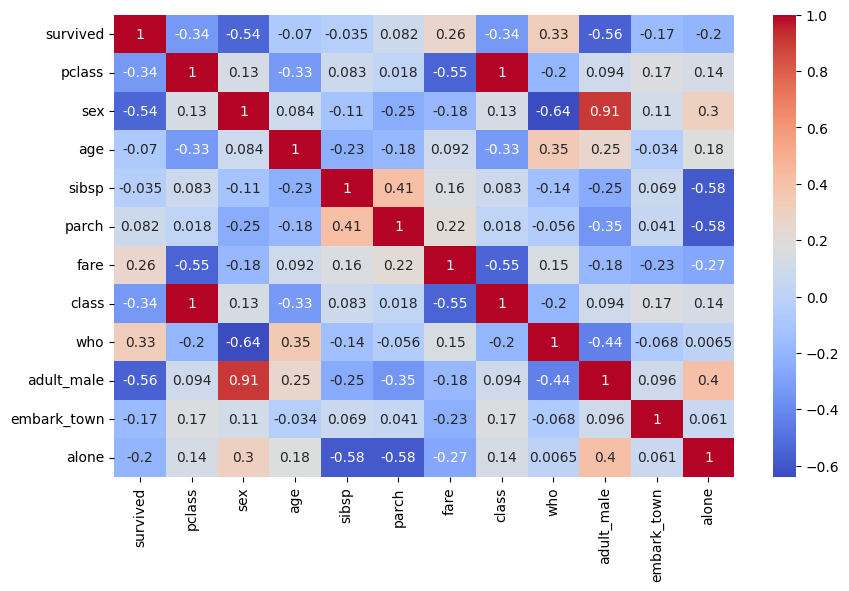

In [46]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True,cmap='coolwarm')

In [49]:
# Typecasting for bool data
df['adult_male'] = df['adult_male'].astype("float64")
df['alone'] = df['alone'].astype("float64")

# Separate data

In [51]:
x = df.drop(['survived'],axis=1)

In [52]:
y = df['survived']

# Train_Test split using on the separate dataset

In [55]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=.2,random_state=42)

# Model Building

In [64]:
lor = LogisticRegression()
model = lor.fit(x_train,y_train)
print("Train score : ", model.score(x_train,y_train))

Train score :  0.8314606741573034


c:\Users\INTEL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [63]:
# test score

print("Test Score : " ,model.score(x_test,y_test) )

Test Score :  0.8156424581005587


In [68]:
# Model Prediction

predict = model.predict(x_test)
predict

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1])

# Model Evalution

In [72]:
# Accuracy_matrix
ac = accuracy_score(y_test,predict)
print("Model Accuracy : " ,ac)

Model Accuracy :  0.8156424581005587


In [73]:
#classificatioin report 

clas_rep = classification_report(y_test,predict)
print(clas_rep)

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.81      0.82      0.81       179



In [74]:
# Confusion matrix
con_max = confusion_matrix(y_test, predict)
con_max

array([[91, 14],
       [19, 55]])

<Axes: >

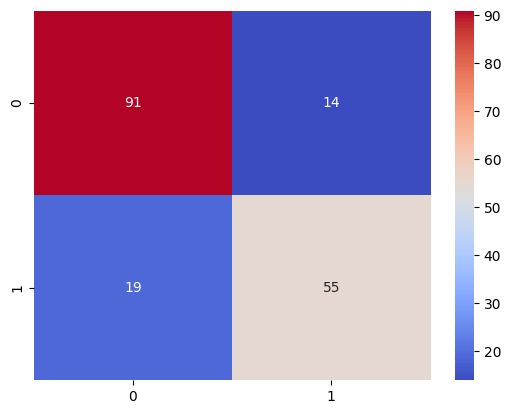

In [75]:
sns.heatmap(con_max,annot=True , cmap="coolwarm")